In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv(r"C:\Users\Maitreya\Desktop\projects\Datasets\human_cognitive_performance.csv")

In [4]:
df.head()

,User_ID,Age,Gender,Sleep_Duration,Stress_Level,Diet_Type,Daily_Screen_Time,Exercise_Frequency,Caffeine_Intake,Reaction_Time,Memory_Test_Score,Cognitive_Score,AI_Predicted_Score
0,U1,57,Female,6.5,3,Non-Vegetarian,6.5,Medium,41,583.33,65,36.71,39.77
1,U2,39,Female,7.6,9,Non-Vegetarian,10.8,High,214,368.24,58,54.35,57.68
2,U3,26,Male,8.2,6,Vegetarian,5.7,Low,429,445.21,49,32.57,29.54
3,U4,32,Male,7.8,9,Vegetarian,8.3,Low,464,286.33,94,70.15,74.59
4,U5,50,Male,9.7,2,Non-Vegetarian,11.3,Medium,365,237.65,62,87.54,91.78


In [5]:
df.isna().any(axis=0)

User_ID               False
Age                   False
Gender                False
Sleep_Duration        False
Stress_Level          False
Diet_Type             False
Daily_Screen_Time     False
Exercise_Frequency    False
Caffeine_Intake       False
Reaction_Time         False
Memory_Test_Score     False
Cognitive_Score       False
AI_Predicted_Score    False
dtype: bool

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   User_ID             80000 non-null  object 
 1   Age                 80000 non-null  int64  
 2   Gender              80000 non-null  object 
 3   Sleep_Duration      80000 non-null  float64
 4   Stress_Level        80000 non-null  int64  
 5   Diet_Type           80000 non-null  object 
 6   Daily_Screen_Time   80000 non-null  float64
 7   Exercise_Frequency  80000 non-null  object 
 8   Caffeine_Intake     80000 non-null  int64  
 9   Reaction_Time       80000 non-null  float64
 10  Memory_Test_Score   80000 non-null  int64  
 11  Cognitive_Score     80000 non-null  float64
 12  AI_Predicted_Score  80000 non-null  float64
dtypes: float64(5), int64(4), object(4)
memory usage: 7.9+ MB


## Target variables - Cognitive Score, Reaction Time

## Predictor - Stress Level

## control variables - age, gender

In [ ]:
df[['Age','Stress_Level','Reaction_Time','Cognitive_Score']].describe(exclude='object')

,Age,Stress_Level,Reaction_Time,Cognitive_Score
count,80000.000000,80000.000000,80000.000000,80000.000000
mean,38.525525,5.493762,399.973579,58.172395
std,12.101876,2.865308,115.369329,23.058522
min,18.000000,1.000000,200.000000,0.000000
25%,28.000000,3.000000,300.150000,40.910000
50%,39.000000,5.000000,400.360000,58.360000
75%,49.000000,8.000000,499.250000,75.830000
max,59.000000,10.000000,599.990000,100.000000


<Axes: ylabel='Density'>

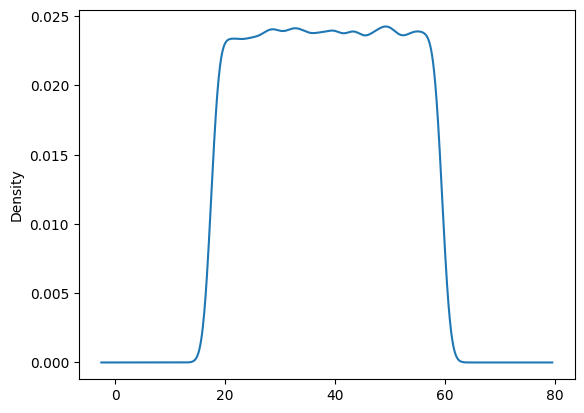

In [ ]:
df.Age.plot(kind='kde')

In [ ]:
#percentage of each gender
df.Gender.value_counts(normalize=True)

Gender
Female    0.480050
Male      0.479025
Other     0.040925
Name: proportion, dtype: float64

the data is not equally divisible among the three gender categories, namely- Female, Male, Other.
About 48% of data is recorded for males, 48% for females and only 4% for other gender(s). This imbalance should be taken into consideration before drawing any conclusion about the distribution of data with respect to 'Gender' feature or before developing any predictive model. Since only 4% of the data has 'Other', distribution of data under this category is more prone to noise and variation compared to other two genders.

In [10]:
# Defining Age Groups
def age_group(x):
    if x <30:
        return 'Young Adult'
    if 30<x<45:
        return 'Average Adult'
    if x>45:
        return 'Old'

In [11]:
df['Age_Group'] = df['Age'].apply(age_group)

In [12]:
df.head()

,User_ID,Age,Gender,Sleep_Duration,Stress_Level,Diet_Type,Daily_Screen_Time,Exercise_Frequency,Caffeine_Intake,Reaction_Time,Memory_Test_Score,Cognitive_Score,AI_Predicted_Score,Age_Group
0,U1,57,Female,6.5,3,Non-Vegetarian,6.5,Medium,41,583.33,65,36.71,39.77,Old
1,U2,39,Female,7.6,9,Non-Vegetarian,10.8,High,214,368.24,58,54.35,57.68,Average Adult
2,U3,26,Male,8.2,6,Vegetarian,5.7,Low,429,445.21,49,32.57,29.54,Young Adult
3,U4,32,Male,7.8,9,Vegetarian,8.3,Low,464,286.33,94,70.15,74.59,Average Adult
4,U5,50,Male,9.7,2,Non-Vegetarian,11.3,Medium,365,237.65,62,87.54,91.78,Old


count    80000.000000
mean        58.172395
std         23.058522
min          0.000000
25%         40.910000
50%         58.360000
75%         75.830000
max        100.000000
Name: Cognitive_Score, dtype: float64


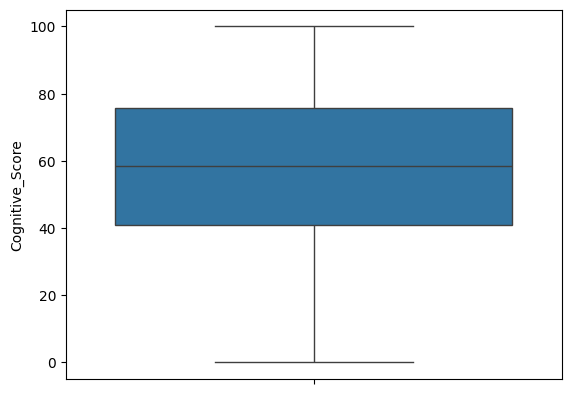

In [26]:
# Cognitive Score Distribution
sns.boxplot(df.Cognitive_Score)
print(df.Cognitive_Score.describe())

,count,mean,std,min,25%,50%,75%,max
Age_Group,,,,,,,,
Average Adult,26819.0,5.488795,2.871495,1.0,3.0,5.0,8.0,10.0
Old,26729.0,5.499158,2.861242,1.0,3.0,5.0,8.0,10.0
Young Adult,22736.0,5.492435,2.860688,1.0,3.0,6.0,8.0,10.0


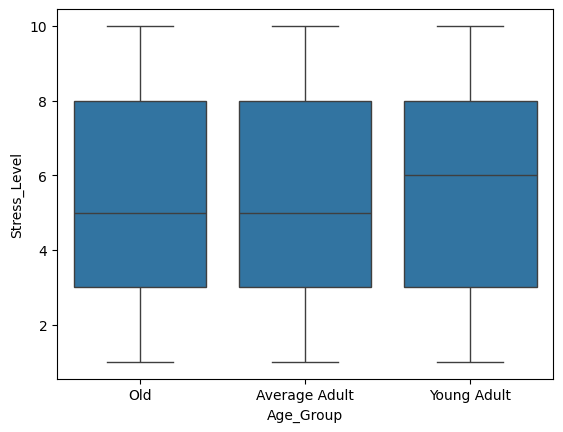

In [27]:
sns.boxplot(data=df,x='Age_Group',y='Stress_Level')
df.groupby('Age_Group')['Stress_Level'].describe()

The Stress Levels among all the three age groups (old, average adult, young adult) have mean of around 5.5 with similar standard deviation of 2.8. However, the median for Young Adults is 6 compared to others which is 5 for them. This suggests that there are more number of Young Adults that have stress levels 6 or higher than there are those with stress level 5 or lower.

<Axes: xlabel='Stress_Level', ylabel='Cognitive_Score'>

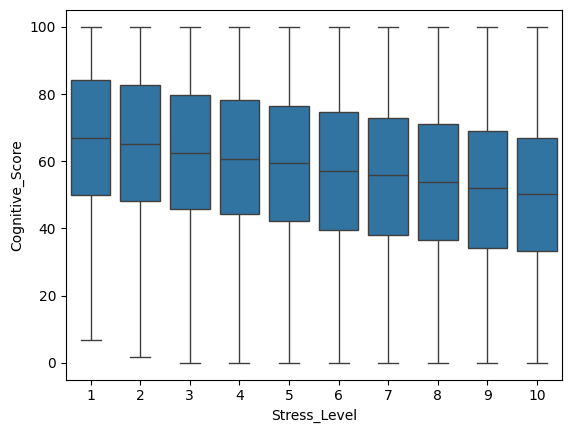

In [16]:
sns.boxplot(df,x='Stress_Level',y='Cognitive_Score')

The above plot shows a negative trend between Cognitive Score and Stres Levels. The median Cognitive Score for each value of stress level drops as the stress level increases, suggesting a negative correlation between Cognitive Score and stress level.

No variation between the age groups.


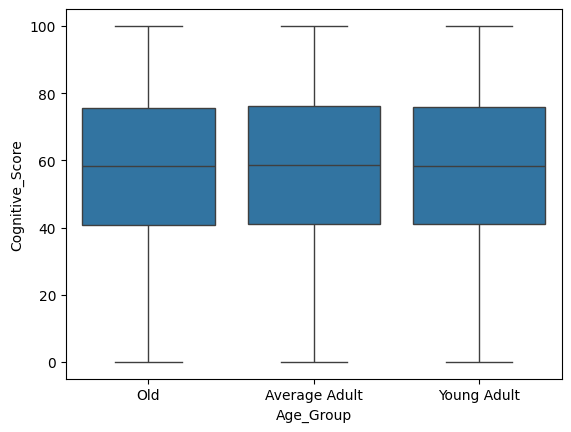

In [43]:
sns.boxplot(df,x='Age_Group',y='Cognitive_Score')
print("No variation between the age groups.")

Correlation between Cognitive Score and Stress Level: -0.22763851488779005


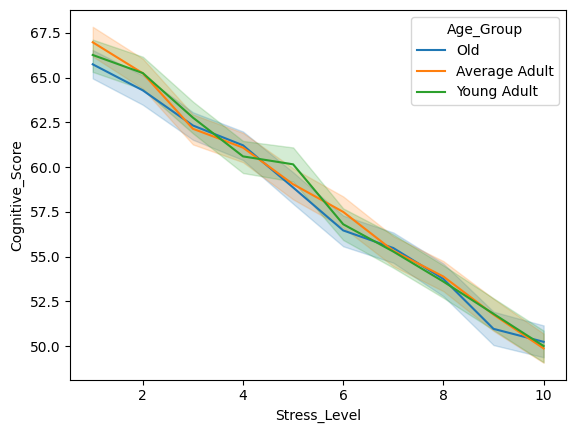

In [40]:
sns.lineplot(data=df,x='Stress_Level',y='Cognitive_Score',hue='Age_Group')
print("Correlation between Cognitive Score and Stress Level:",df.Cognitive_Score.corr(df.Stress_Level))

<Axes: xlabel='Age_Group', ylabel='Reaction_Time'>

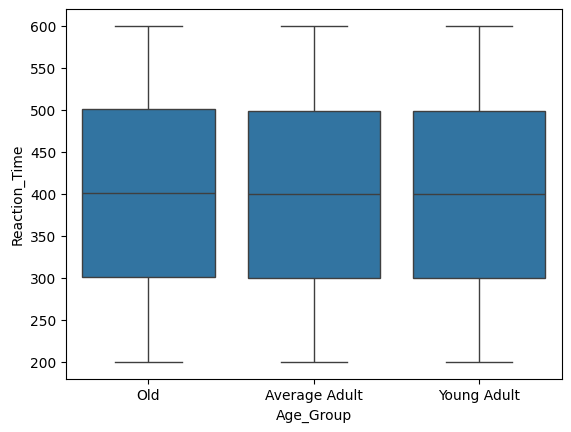

In [17]:
sns.boxplot(data=df,x='Age_Group',y='Reaction_Time')

The Reaction Time is distributed identically between the Age groups.
Median around 400ms

<Axes: xlabel='Gender', ylabel='Reaction_Time'>

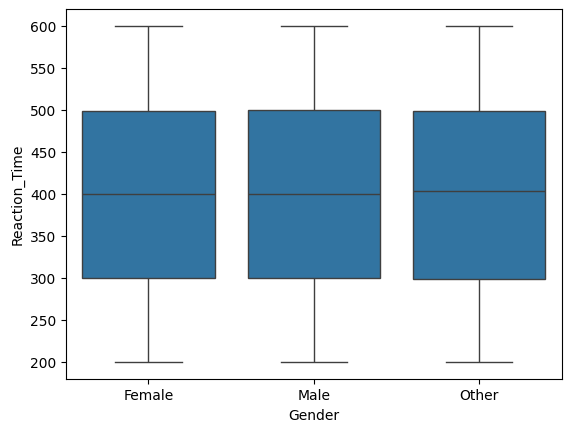

In [13]:
sns.boxplot(data=df,x='Gender',y='Reaction_Time')

 The median and the distribution of Reaction-Time are almost identical across the Gender.
 
 50 percentile of the data(25th %tile - 75th %tile) falls under the range of ~300ms-500ms with the median centred around 400ms.


<Axes: xlabel='Stress_Level', ylabel='Cognitive_Score'>

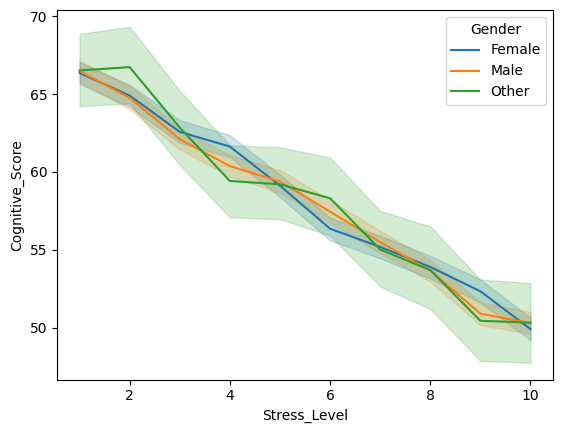

In [21]:
sns.lineplot(data=df,x='Stress_Level',y='Cognitive_Score',hue='Gender')

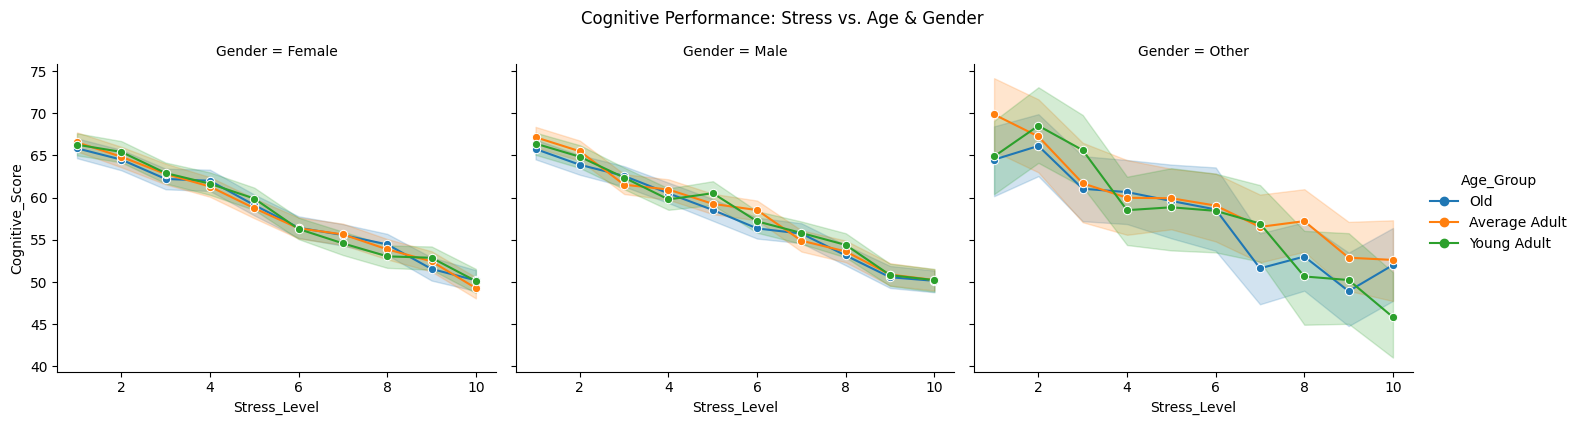

Correlation by Gender (Stres Level vs Coginitive Score)
Female : -0.2277
Male : -0.2267
Other : -0.2377
Correlation by Age_Groups (Stres Level vs Coginitive Score)
Average Adult : -0.2325
Old : -0.2222
Young Adult : -0.2294


In [41]:
plot = sns.relplot(
    data=df, 
    x='Stress_Level', 
    y='Cognitive_Score', 
    hue='Age_Group', 
    col='Gender',
    kind='line', 
    marker='o',
    height=4, 
    aspect=1.2
)

plot.fig.suptitle('Cognitive Performance: Stress vs. Age & Gender', y=1.05)
plt.show()

print("Correlation by Gender (Stres Level vs Coginitive Score)")
for gender, subdf in df.groupby('Gender'):
    r = subdf['Stress_Level'].corr(subdf['Cognitive_Score'])
    print(f"{gender} : {r:.4f}")

print("Correlation by Age_Groups (Stres Level vs Coginitive Score)")
for group, subdf in df.groupby('Age_Group'):
    r = subdf['Stress_Level'].corr(subdf['Cognitive_Score'])
    print(f"{group} : {r:.4f}")



The above plot shows a multi-variate analysis between cognitive score, stress levels, gender and age group.

Result: No significant variation in correlation between cognitive score and stress levels acorss or in gender or age groups categories. Overall correlation between Cognitive Score and Stress Levels is ~ -0.23. We can conclude from this that there is a weak correlation between these two.

<Axes: xlabel='Age', ylabel='Cognitive_Score'>

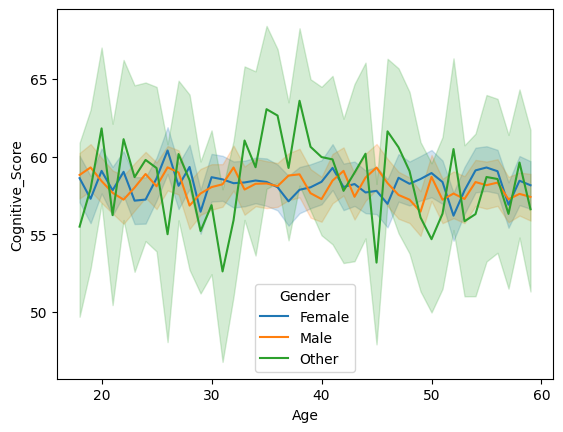

In [ ]:
sns.lineplot(df,x='Age',y='Cognitive_Score',hue='Gender')

The data for 'Other' gender value has more noise and variations. However, this can be purely caused by the smaller data size for this value compared to males and females. In case of larger size for other two values, the noise cancels out more evenly resulting a smoother line along the mean. On the other hand, with smaller samples, the extremes don't get cancel out evenly.

In [37]:
df.groupby('Age_Group').Reaction_Time.describe()

,count,mean,std,min,25%,50%,75%,max
Age_Group,,,,,,,,
Average Adult,26819.0,399.428290,115.489725,200.00,299.590,399.41,498.77,599.98
Old,26729.0,400.892904,115.616213,200.02,300.760,401.54,500.97,599.99
Young Adult,22736.0,399.656175,115.022360,200.02,299.735,400.45,498.22,599.99


<Axes: xlabel='Age_Group', ylabel='Stress_Level'>

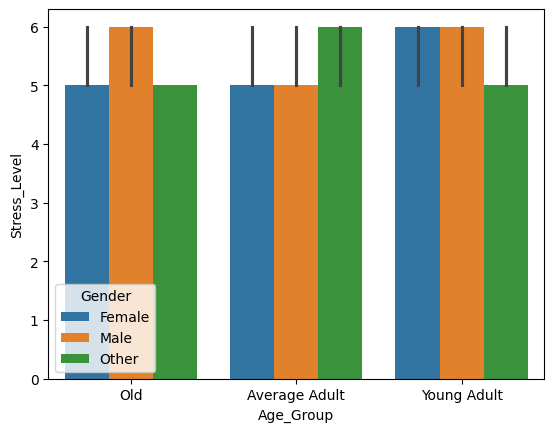

In [ ]:
sns.barplot(df,x='Age_Group',y='Stress_Level',hue='Gender',estimator='median')

The Stress Level break down by Age group that is broken down by different gender shows different medians for different genders inside age groups.

Males in Older age group, Other gender(s) in Average Adult group and both males and females in Young adults have higher (median= 6) than rest of the gender(median = 5) in their respective age groups.


While medians are different same analysis for mean shows relatively closer means in each gender inside the age groups.

<Axes: xlabel='Age_Group', ylabel='Stress_Level'>

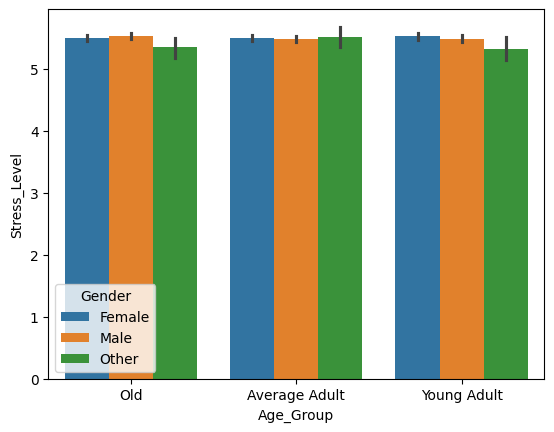

In [ ]:
sns.barplot(df,x='Age_Group',y='Stress_Level',hue='Gender',estimator='mean')

<Axes: xlabel='Gender', ylabel='Stress_Level'>

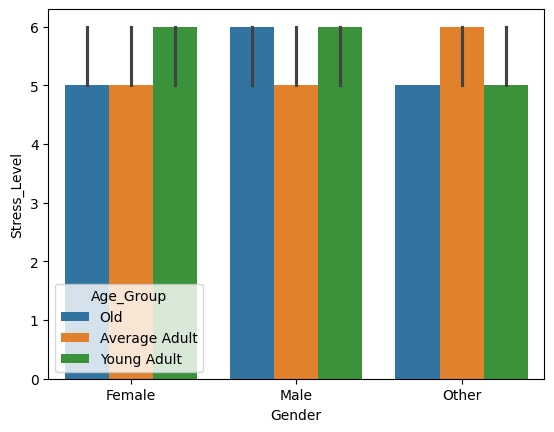

In [ ]:
sns.barplot(df,x='Gender',y='Stress_Level',hue='Age_Group',estimator='median')

Above is a different plot broken down with the same control variables: gender and age groups but the genders are further broken down by age groups. Here the findings are clearer than the previous analysis.

For females: Young Adult

For males: Old, Young Adult

For other: Average Adult

have higher median than other age groups in the same gender.

Conclusion: Males are more stressed in Young adult age and Old age than Average adult phase. Females are more stressed in their young adult age than in old age or average adult age. Other gender(s) are more stressed in their average adult age.

Question: Is this pattern factual and grounded in real world?. If yes, then what could be the possible explaination? Or is this because of the fact that the dataset is synthesized?


In [45]:
print("The Correlation between Cognitive Score and Reaction-Time:", df.Cognitive_Score.corr(df.Reaction_Time))

The Correlation between Cognitive Score and Reaction-Time: -0.8184700620396137


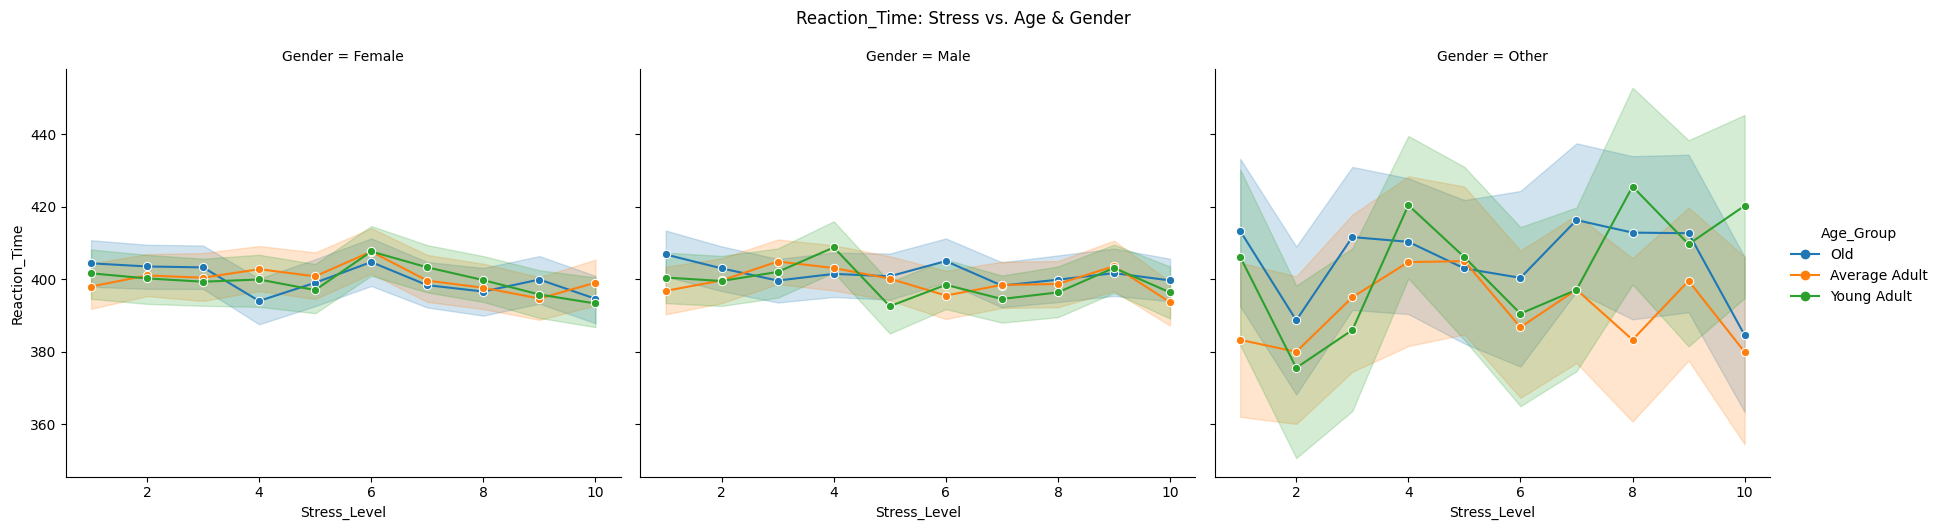

Correlation by Gender (Stres Level vs Reaction Time)
Female : -0.0131
Male : -0.0121
Other : 0.0177
Correlation by Age Group (Stres Level vs Reaction Time)
Average Adult : -0.0078
Old : -0.0153
Young Adult : -0.0091


In [42]:
plot = sns.relplot(
    data=df, 
    x='Stress_Level', 
    y='Reaction_Time', 
    hue='Age_Group', 
    col='Gender',
    kind='line', 
    marker='o',
    height=5, 
    aspect=1.2
)

plot.fig.suptitle('Reaction_Time: Stress vs. Age & Gender', y=1.05)
plt.show()

print("Correlation by Gender (Stres Level vs Reaction Time)")
for gender, subdf in df.groupby('Gender'):
    r = subdf['Stress_Level'].corr(subdf['Reaction_Time'])
    print(f"{gender} : {r:.4f}")


print("Correlation by Age Group (Stres Level vs Reaction Time)")
for group, subdf in df.groupby('Age_Group'):
    r = subdf['Stress_Level'].corr(subdf['Reaction_Time'])
    print(f"{group} : {r:.4f}")

Although there is a strong correlation between Cognitive Score and Reaction Time and a weak correlation between Cognitive Score and Stress level, surprisingly there is a very strong correlation between Cognitive,there seems to be almost zero correlation between Reaction-Time and Stress levels. Even among different Gender or age Groups, there is no difference in correlation.

Explaination: Correlation is not transitive. Therefore, this case is possible in real world too. Or the data is not synthezied with enough complexity to account for the interaction between different variables.

In [ ]:
# Check the spread of stress levels for these specific groups
print(df.groupby(['Gender', 'Age_Group'])['Stress_Level'].std())

Gender  Age_Group    
Female  Average Adult    2.865268
        Old              2.871545
        Young Adult      2.868512
Male    Average Adult    2.881860
        Old              2.850533
        Young Adult      2.852831
Other   Average Adult    2.824691
        Old              2.862478
        Young Adult      2.856666
Name: Stress_Level, dtype: float64


Stress levels among both control variables are tightly distributed having the standard deviation of about 2.5-2.8 for each combination. This a huge marker of the synthetic nature of the data.

In [ ]:
df_numeric = df.select_dtypes(include='number')

<Axes: >

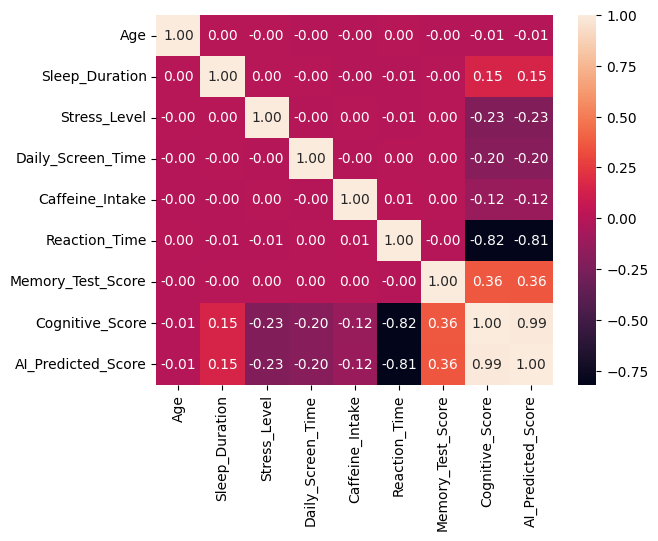

In [ ]:
sns.heatmap(df_numeric.corr(),annot=True
            , fmt=".2f")

Discussion Questions:

1. How trustful and grounded are the findings with respect to the real world?
2. What could be the reason for the no correlation between stress levels and reaction time?
3. Is there a difference in stress levels in different genders at different stages of life?